---
title: 'Wykład 5: Różniczkowanie automatyczne i wsteczna propagacja'
subtitle: Biblioteki Python w analizie danych
author: Tomasz Rodak
---

## Motywacja: dlaczego ręczne liczenie gradientu nas zawodzi

Na wykładzie 4 oraz w lab 8 wyprowadzaliśmy gradient funkcji straty ręcznie. Dla regresji liniowej z MSE i regresji logistycznej z BCE wzór miał ładną, wspólną postać:

\begin{equation*}
\nabla_{\mathbf{w}} L = \frac{1}{N} X^T (\hat{\mathbf{y}} - \mathbf{y}).
\end{equation*}

Wystarczyło jedno zastosowanie reguły łańcuchowej, krótkie wyprowadzenie i jedna linijka kodu w pętli treningowej.

Załóżmy teraz, że chcemy wytrenować trochę bogatszy model — sieć z jedną warstwą ukrytą:

\begin{equation*}
\hat{y} = \sigma\!\left(\text{ReLU}(\mathbf{x}^T W_1 + \mathbf{b}_1)\, W_2 + b_2\right).
\end{equation*}

Aby zastosować mini-batch gradient descent, potrzebujemy gradientów funkcji straty względem każdego z parametrów $W_1$, $\mathbf{b}_1$, $W_2$, $b_2$. Wyprowadzenie $\partial L / \partial W_1$ wymaga kilkukrotnego zastosowania reguły łańcuchowej, sumy iloczynów Hadamarda z pochodnymi funkcji aktywacji i ostrożnego pilnowania kształtów tensorów. Dla sieci konwolucyjnych z wykładu 6 — z kilkunastoma warstwami i nieliniowościami — ręczne wyprowadzanie jest praktycznie niewykonalne.

Potrzebujemy mechanizmu, który zrobi to za nas: weźmie dowolny model zapisany jako sekwencję operacji tensorowych i automatycznie obliczy gradient straty względem wszystkich parametrów. Takim mechanizmem jest **różniczkowanie automatyczne** (*automatic differentiation*, *autograd*) wbudowane w PyTorch. Zanim opiszemy, jak się go używa, spójrzmy na ideę, która stoi za nim.

## Graf obliczeniowy

Każdą sekwencję operacji tensorowych można przedstawić jako skierowany graf acykliczny:

* **Liście** to tensory wejściowe i parametry modelu.
* **Węzły wewnętrzne** to wyniki operacji elementarnych (mnożenie, dodawanie, funkcje aktywacji itp.) zastosowanych do swoich rodziców.
* **Korzeń** to skalarna funkcja straty $L$.

Rozważmy bardzo prosty przykład: pojedynczy neuron z sigmoidą i stratą kwadratową dla jednej próbki:

\begin{equation*}
z = xw + b, \qquad \hat{y} = \sigma(z), \qquad L = (y - \hat{y})^2.
\end{equation*}

Graf obliczeniowy wygląda tak:

```
   x      w      b      y
    \     /      |      |
     \   /       |      |
      \ /        |      |
      [* ]       |      |
        \        |      |
         \       /      |
          \     /       |
           [+ ]         |
              \         |
              [σ]       |
                \      /
                 \    /
                 [-  ]
                   |
                  [^2]
                   |
                   L
```

Pierwsze przejście — od liści do korzenia — to **forward pass**: liczymy wartości węzeł po węźle, zapamiętując wyniki pośrednie. Tak właśnie działała każda nasza pętla treningowa do tej pory.

Po forward passie znamy wartość $L$. Pytanie: jak obliczyć gradienty $\partial L / \partial w$ i $\partial L / \partial b$?

## Reguła łańcuchowa i wsteczna propagacja

Dla naszego mini-przykładu można po prostu zwinąć całą funkcję w jeden wzór i policzyć pochodne. Jeśli jednak graf ma kilkadziesiąt węzłów, takie podejście jest nieefektywne, bo wielokrotnie liczy te same pochodne cząstkowe.

Aby zapis był zwięzły, wprowadźmy notację: dla każdego węzła $v$ w grafie obliczeniowym definiujemy

\begin{equation*}
\bar{v} := \frac{\partial L}{\partial v}.
\end{equation*}

Wielkość $\bar{v}$ czytamy jako „gradient straty $L$ względem węzła $v$" — to właśnie to, co chcemy obliczyć dla każdego liścia będącego parametrem modelu. Dla samego korzenia mamy trywialnie $\bar{L} = \partial L / \partial L = 1$.

Reguła łańcuchowa w wieloparametrowej postaci mówi, że jeśli węzeł $v$ wpływa na $L$ poprzez wszystkie swoje dzieci $u_1, \ldots, u_k$ (czyli węzły obliczone bezpośrednio z użyciem $v$), to:

\begin{equation*}
\bar{v} = \sum_{i=1}^{k} \bar{u_i} \cdot \frac{\partial u_i}{\partial v}.
\end{equation*}

To kluczowa obserwacja: gradient $\bar{v}$ wyraża się przez gradienty $\bar{u_i}$ jego dzieci pomnożone przez **lokalne** pochodne $\partial u_i / \partial v$, czyli pochodne pojedynczych operacji wykonanych w grafie. Skoro tak, to gradienty wszystkich węzłów można policzyć w jednym przejściu po grafie — od korzenia w stronę liści — pod warunkiem, że gdy dochodzimy do węzła $v$, jego dzieci zostały już przetworzone i znamy ich gradienty.

Ten wzorzec — przebieg po grafie od końca do początku — to **algorytm wstecznej propagacji** (*backpropagation*).

**Algorytm wstecznej propagacji**:

1. Wykonaj forward pass: oblicz i zapamiętaj wartości wszystkich węzłów.
2. Zainicjalizuj gradienty: $\bar{L} \gets 1$ oraz $\bar{v} \gets 0$ dla wszystkich pozostałych węzłów.
3. Przechodź po węzłach $v$ w kolejności **odwrotnej topologicznej** (od korzenia do liści). Gdy odwiedzasz $v$, jego gradient $\bar{v}$ jest już w pełni policzony — wszystkie dzieci $v$ wpisały już swoje wkłady. Teraz $v$ rozdziela ten gradient do swoich rodziców: dla każdego rodzica $p$ (węzła, z którego $v$ został obliczony) wykonaj aktualizację

\begin{equation*}
\bar{p} \mathrel{+}= \bar{v} \cdot \frac{\partial v}{\partial p}.
\end{equation*}

4. Zwróć gradienty $\bar{w}$ zgromadzone w liściach grafu odpowiadających parametrom modelu.

Dwie obserwacje:

**Każda krawędź grafu przetwarzana jest dokładnie raz.** Krawędź $p \to v$ generuje w punkcie 3 jeden wkład $\bar{v} \cdot \partial v / \partial p$ do gradientu $\bar{p}$. Gradient każdego węzła jest akumulowany z wkładów pochodzących od wszystkich operacji, które tego węzła użyły. Złożoność czasowa algorytmu jest więc tego samego rzędu co forward pass.

**Algorytm jest mechaniczny i niezależny od konkretnego modelu.** Ważne jest tylko to, by każda operacja używana w forward passie miała zaimplementowaną swoją lokalną pochodną $\partial v / \partial p$. Reszta to systematyczne stosowanie reguły łańcuchowej w odpowiedniej kolejności.

### Mały przykład

Prześledźmy backprop krok po kroku na grafie z poprzedniej sekcji. Cel jest trojaki:

* zobaczyć, że cały algorytm to **mechaniczne podstawianie lokalnych pochodnych** do reguły łańcuchowej, bez żadnych globalnych wyprowadzeń;
* zauważyć, że backward pass **wykorzystuje wartości zapamiętane w forward passie** — np. pochodna sigmoidy ma postać $\sigma'(z) = \sigma(z)(1-\sigma(z)) = \hat{y}(1-\hat{y})$, więc odwołuje się do $\hat{y}$ obliczonego wcześniej;
* zobaczyć, że pośredni gradient $\bar{z}$ liczony jest **raz**, a następnie używany **wielokrotnie** — tu w aktualizacjach gradientów wszystkich trzech rodziców węzła $z$.

**Forward pass** sprowadza się do trzech zapamiętanych wyrażeń:

\begin{equation*}
z = xw + b, \qquad \hat{y} = \sigma(z), \qquad L = (y - \hat{y})^2.
\end{equation*}

**Backward pass** (zaczynamy od $\bar{L} = 1$ i schodzimy po grafie):

* Węzeł $L = (y - \hat{y})^2$. Lokalna pochodna $\partial L / \partial \hat{y} = -2(y - \hat{y})$. Stąd

  \begin{equation*}
  \bar{\hat{y}} = \bar{L} \cdot \frac{\partial L}{\partial \hat{y}} = -2(y - \hat{y}).
  \end{equation*}
* Węzeł $\hat{y} = \sigma(z)$. Lokalna pochodna $\partial \hat{y} / \partial z = \hat{y}(1-\hat{y})$ — **odwołuje się wprost do wartości $\hat{y}$ zapamiętanej w forward passie**. Stąd

  \begin{equation*}
  \bar{z} = \bar{\hat{y}} \cdot \hat{y}(1-\hat{y}).
  \end{equation*}

* Węzeł $z = xw + b$ ma trzech rodziców: $x$, $w$, $b$. Lokalne pochodne to $\partial z / \partial x = w$, $\partial z / \partial w = x$, $\partial z / \partial b = 1$. **Z tej samej wartości $\bar{z}$ wyciągamy trzy wkłady**:
    * $\bar{w} \mathrel{+}= \bar{z} \cdot x$,
    * $\bar{b} \mathrel{+}= \bar{z}$,
    * $\bar{x} \mathrel{+}= \bar{z} \cdot w$ (dla danych nieużywany, ale taki wkład powstaje).

Trzy rzeczy są godne uwagi. Po pierwsze, w żadnym momencie nie wyprowadzaliśmy wzoru na $\partial L / \partial w$ jako takiego — gdybyśmy chcieli, moglibyśmy teraz zwinąć wszystkie kroki w jeden łańcuch:

\begin{equation*}
\bar{w} = -2(y - \hat{y}) \cdot \hat{y}(1-\hat{y}) \cdot x,
\end{equation*}

ale algorytm wstecznej propagacji nigdy tego wzoru jawnie nie utworzył — wstawiał tylko lokalne pochodne pojedynczych operacji i mnożył. Dla sieci z dziesiątkami warstw taka jawna kompozycja byłaby niewykonalna, a backprop poradzi sobie z nią bez różnicy. Po drugie, backward pass jawnie korzysta z zapamiętanej wartości $\hat{y}$; **pamięć potrzebna na trening sieci jest proporcjonalna do liczby aktywacji w forward passie**, nie tylko do liczby parametrów. Po trzecie, gradient $\bar{z}$ został policzony raz i posłużył do trzech aktualizacji — po jednej dla każdego rodzica $z$. Ten *reuse* jest źródłem efektywności backprop: każdy gradient pośredni liczony jest raz, niezależnie od tego, ile liści grafu na końcu od niego zależy.

Te trzy własności — mechaniczność, użycie zapamiętanych wartości forward passu i wielokrotne użycie gradientów pośrednich — są jądrem każdej implementacji autograd, w tym tej w PyTorchu, którą poznamy w następnej sekcji.


## Autograd w PyTorch

Mechanizm wstecznej propagacji opisany powyżej jest tak ogólny, że nie wymaga, byśmy go sami implementowali — wystarczy, żeby biblioteka tensorowa robiła trzy rzeczy:

1. zapamiętywała w trakcie forward passu, jakie operacje wykonano i na jakich tensorach,
2. dla każdej operacji znała wzór na lokalną pochodną,
3. udostępniała funkcję, która wywoła backward pass.

PyTorch robi dokładnie to. Mechanizm nazywa się **autograd**.

### Tensory śledzone przez autograd

Aby PyTorch zaczął śledzić operacje na tensorze, ustawiamy mu flagę `requires_grad=True`:

In [1]:
import torch

w = torch.tensor([1.5], requires_grad=True)
b = torch.tensor([-1.0], requires_grad=True)
x = torch.tensor([2.0])  # bez requires_grad — to dane, nie parametr
y = torch.tensor([1.0])

Teraz każda operacja, w której wystąpi `w` lub `b`, doklei nowy węzeł do grafu obliczeniowego budowanego dynamicznie:

In [2]:
z = x * w + b
y_hat = torch.sigmoid(z)
loss = (y - y_hat) ** 2

print(z)
print(y_hat)
print(loss)

tensor([2.], grad_fn=<AddBackward0>)
tensor([0.8808], grad_fn=<SigmoidBackward0>)
tensor([0.0142], grad_fn=<PowBackward0>)


Każdy z tych tensorów wie, jaką operacją został utworzony — atrybut `grad_fn` wskazuje na funkcję wstecznego przejścia dla swojej operacji:

In [3]:
print(z.grad_fn)
print(y_hat.grad_fn)
print(loss.grad_fn)

`x` i `y` nie mają `grad_fn`, bo nie były tworzone przez żadną śledzoną operację — są liśćmi grafu, ale liśćmi „zewnętrznymi", nie parametrami.

### `backward()` i atrybut `.grad`

Aby uruchomić wsteczną propagację, wywołujemy `loss.backward()`. PyTorch przechodzi po grafie od korzenia (wartości skalarnej `loss`) do liści z `requires_grad=True` i wypełnia ich atrybut `.grad`:

In [4]:
loss.backward()

print(f"w.grad = {w.grad.item():.4f}")
print(f"b.grad = {b.grad.item():.4f}")

w.grad = -0.0501
b.grad = -0.0250


Otrzymane wartości zgadzają się z naszym ręcznym wyliczeniem z poprzedniej sekcji ($\bar{w} \approx -0.0500$, $\bar{b} \approx -0.0250$) — tylko że nie musieliśmy nic wyprowadzać. Cała magia kryje się w `loss.backward()`.

### Ważne ograniczenia i konwencje

**`backward()` można wywołać tylko na skalarze.** Jeśli chcielibyśmy zróżniczkować coś, co nie jest skalarem (np. wektor strat dla wielu próbek), musielibyśmy podać wektor wag — ale w praktyce zawsze redukujemy do skalara przez `.mean()` lub `.sum()`.

**Gradienty się akumulują.** Każde kolejne wywołanie `.backward()` *dodaje* nowe wartości do `.grad`, zamiast je zastępować. To celowe — dzięki temu można sumować gradienty z kilku batchy przed aktualizacją, ale w typowej pętli treningowej trzeba pamiętać, żeby przed kolejnym backward passem wyzerować gradienty:

In [5]:
w.grad.zero_()
b.grad.zero_()

tensor([0.])

**Forward pass z `requires_grad=True` zużywa pamięć.** PyTorch zapamiętuje wartości pośrednie potrzebne do backward passu. Dla treningu to konieczne, ale przy predykcji czy walidacji jest to marnotrawstwo.

### `torch.no_grad()` i `.detach()`

Są dwa sposoby na wyłączenie śledzenia operacji.

**`torch.no_grad()`** to menedżer kontekstu, w którym nic nie jest śledzone, mimo że tensory wciąż mają `requires_grad=True`:

In [6]:
with torch.no_grad():
    y_pred = torch.sigmoid(x * w + b)
    print(f"y_pred ma grad_fn: {y_pred.grad_fn is not None}")

y_pred ma grad_fn: False


Stosujemy go zawsze, gdy nie planujemy liczyć gradientu — w pętli walidacyjnej, przy predykcji na nowych danych, oraz przy ręcznej aktualizacji wag (do tego wrócimy w sekcji o sieci „od dołu").

**`.detach()`** zwraca nowy tensor o tej samej zawartości, ale odcięty od grafu obliczeniowego:

In [7]:
y_hat_detached = y_hat.detach()
print(f"y_hat_detached.grad_fn: {y_hat_detached.grad_fn}")

y_hat_detached.grad_fn: None


Używamy go, gdy chcemy zatrzymać propagację gradientu w konkretnym miejscu grafu — np. konwertując tensor PyTorch do tablicy NumPy do wizualizacji, gdzie graf nie jest już potrzebny.

### Kontrolny eksperyment: ręczny gradient vs autograd

Zweryfikujmy, że dla regresji liniowej z lab 8 autograd daje dokładnie ten sam gradient co nasz ręczny wzór $\nabla_{\mathbf{w}} L = -\frac{2}{N} X^T (\mathbf{y} - X\mathbf{w})$.

In [8]:
torch.manual_seed(0)
N, d = 50, 3
X = torch.randn(N, d + 1)
y = torch.randn(N)
w = torch.randn(d + 1, requires_grad=True)

# Ręczny wzór
y_pred = X @ w
residuals = y - y_pred
grad_manual = -2.0 / N * (X.T @ residuals)

# Autograd
loss = ((y - X @ w) ** 2).mean()
loss.backward()
grad_auto = w.grad

print(f"Maksymalna różnica: {(grad_manual.detach() - grad_auto).abs().max().item():.2e}")

Maksymalna różnica: 9.54e-07


Zgadza się co do precyzji numerycznej. Tym samym mamy potwierdzenie, że jeśli kiedyś byliśmy w stanie wyprowadzić gradient ręcznie, to autograd da nam dokładnie ten sam wynik — z tą różnicą, że w przypadku autograd nie musieliśmy nic wyprowadzać.

## Sieć dwuwarstwowa zbudowana „od dołu"

Mając autograd, możemy wytrenować sieć z warstwą ukrytą bez wyprowadzania jakichkolwiek gradientów. Pokażmy to na prostym zadaniu regresji nieliniowej, w którym regresja liniowa byłaby bezradna.

### Dane

Generujemy próbki z funkcji $y = \sin(2\pi x) + \varepsilon$ na $x \in [0, 1]$:

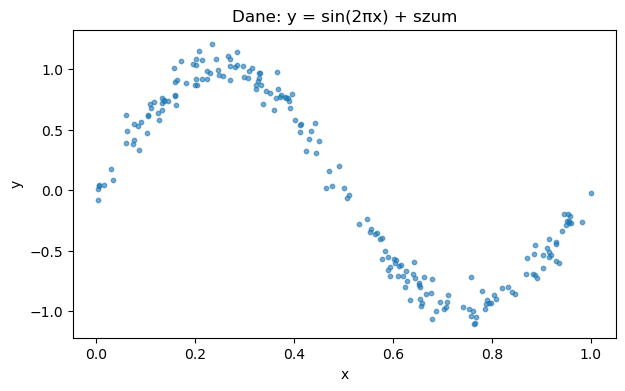

In [9]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
N = 200
x = torch.rand(N, 1)               # kształt (N, 1)
y = torch.sin(2 * torch.pi * x) + 0.1 * torch.randn(N, 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x.numpy(), y.numpy(), s=10, alpha=0.6)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Dane: y = sin(2πx) + szum");

### Model

Sieć ma jedną warstwę ukrytą o szerokości $H = 16$ z aktywacją ReLU i liniową warstwą wyjściową:

\begin{equation*}
\hat{y} = \text{ReLU}(x W_1 + \mathbf{b}_1)\, W_2 + b_2,
\end{equation*}

gdzie $W_1 \in \mathbb{R}^{1 \times H}$, $\mathbf{b}_1 \in \mathbb{R}^H$, $W_2 \in \mathbb{R}^{H \times 1}$, $b_2 \in \mathbb{R}$.

Parametry inicjalizujemy małymi wartościami losowymi i oznaczamy `requires_grad=True`:

In [53]:
H = 64

W1 = torch.randn(1, H, requires_grad=True)
b1 = torch.zeros(H, requires_grad=True)
W2 = torch.randn(H, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

Forward pass piszemy jako sekwencję operacji tensorowych:

In [54]:
def forward(x):
    h = torch.relu(x @ W1 + b1)   # warstwa ukryta, kształt (N, H)
    return h @ W2 + b2            # wyjście, kształt (N, 1)

### Pętla treningowa

Trening wykonujemy w trybie batch GD (wszystkie 200 próbek na raz — zbiór jest mały). Strata to MSE. Każda iteracja składa się z czterech kroków: forward, backward, aktualizacja wag w `torch.no_grad()`, wyzerowanie gradientów.

In [55]:
lr = 0.01
num_iter = 10_000
history = []

for it in range(num_iter):
    # Forward
    y_pred = forward(x)
    loss = ((y - y_pred) ** 2).mean()

    # Backward — autograd liczy gradienty wszystkich parametrów
    loss.backward()

    # Aktualizacja wag — w no_grad, żeby nie dokleić tego do grafu
    with torch.no_grad():
        for p in (W1, b1, W2, b2):
            p -= lr * p.grad
            p.grad.zero_()        # czyszczenie gradientu na następną iterację

    history.append(loss.item())

print(f"MSE końcowe: {history[-1]:.4f}")

MSE końcowe: 0.0094


Trzy szczegóły implementacyjne warto skomentować.

**Aktualizacja w `torch.no_grad()`.** Operacja `p -= lr * p.grad` modyfikuje tensor `p`, który ma `requires_grad=True`. Bez `no_grad()` PyTorch dokleiłby tę operację do grafu obliczeniowego, co spowodowałoby błąd przy następnym `backward()` (próba różniczkowania w miejscu zmienionym poza grafem).

**`p -= lr * p.grad` zamiast `p = p - lr * p.grad`.** Druga forma utworzyłaby nowy tensor (bez `requires_grad`) i przypisała go do nazwy `p`, ale nasza krotka `(W1, b1, W2, b2)` nadal wskazywałaby na stare tensory. Operacja in-place modyfikuje pamięć istniejącego tensora.

**`p.grad.zero_()` po każdej iteracji.** Bez tego gradienty zaczęłyby się akumulować z iteracji na iterację, co dawałoby coraz większe i coraz bardziej zaszumione kroki.

### Wyniki

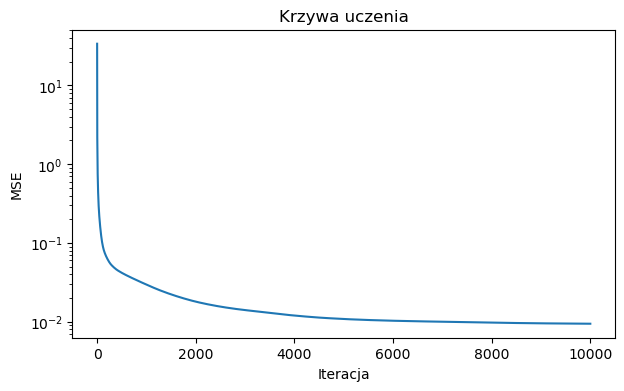

In [56]:
# Krzywa uczenia
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history)
ax.set_xlabel("Iteracja"); ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_title("Krzywa uczenia");

Aby zobaczyć dopasowanie modelu, predykcję wykonujemy w `torch.no_grad()`:

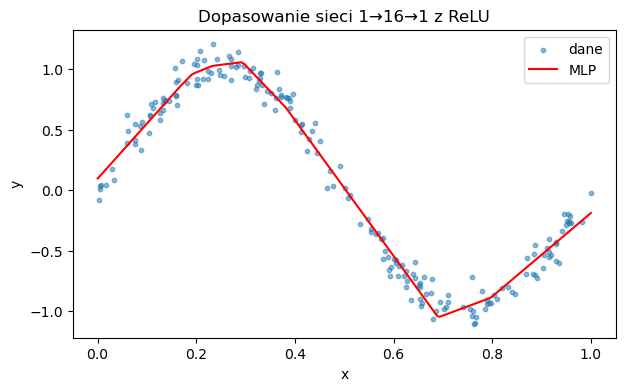

In [57]:
x_grid = torch.linspace(0, 1, 200).reshape(-1, 1)
with torch.no_grad():
    y_grid = forward(x_grid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x.numpy(), y.numpy(), s=10, alpha=0.5, label="dane")
ax.plot(x_grid.numpy(), y_grid.numpy(), color="red", label="MLP")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(); ax.set_title("Dopasowanie sieci 1→16→1 z ReLU");

Sieć z 64 neuronami w warstwie ukrytej dobrze odtwarza sinusoidę — czego regresja liniowa nie potrafi zrobić w ogóle, a regresja z bazami Gaussa z lab 8 wymagała ręcznego wyprowadzenia bazy. Tutaj dostajemy uniwersalny aproksymator za darmo: wystarczyły cztery linijki forward passu i jedna linijka `loss.backward()`.

To ważny moment. Mamy w rękach narzędzie wystarczające do wytrenowania **dowolnej** architektury wyrażalnej jako kompozycja operacji tensorowych. Ale kod robi się powtarzalny: ręczna inicjalizacja parametrów, ręczne pisanie forward passu jako sekwencji wyrażeń macierzowych, ręczne iterowanie po krotce parametrów. Następne sekcje pokazują, jak PyTorch te powtarzalności automatyzuje.

## `torch.nn` — kolejny poziom abstrakcji

Moduł `torch.nn` wprowadza dwa pojęcia, które porządkują kod sieci neuronowych: **warstwy** (`nn.Linear`, `nn.Conv2d`, ...) i **moduły** (`nn.Module`).

### `nn.Linear`

Warstwa $y = xW + b$ dostępna jest jako gotowa klasa:

In [58]:
import torch.nn as nn

linear = nn.Linear(in_features=1, out_features=16)
print(linear.weight.shape)  # (16, 1) — uwaga: PyTorch trzyma W transponowane!
print(linear.bias.shape)    # (16,)

torch.Size([16, 1])
torch.Size([16])


Wagi i bias są od razu zarejestrowane jako parametry z `requires_grad=True` i zainicjalizowane sensownie (domyślnie wariantem inicjalizacji Kaiminga). Wywołanie `linear(x)` wykonuje mnożenie macierzowe i dodanie biasu.

### Funkcje aktywacji

Najpopularniejsze aktywacje są dostępne w dwóch wariantach.

**Jako klasy** (warstwy bez parametrów) — używamy ich, gdy budujemy model przez `nn.Sequential` lub `nn.Module`:

```python
nn.ReLU(), nn.Sigmoid(), nn.Tanh(), nn.Softmax(dim=...)
```

**Jako funkcje** w `torch.nn.functional` (zwyczajowo importowane jako `F`):

```python
import torch.nn.functional as F
F.relu(x), F.sigmoid(x), F.softmax(x, dim=...)
```

Oba warianty dają identyczne wyniki. Wybór jest stylistyczny: klasy są wygodniejsze przy `nn.Sequential`, funkcje czytelniejsze, gdy forward pass jest pisany ręcznie.

### `nn.Module` — klasa bazowa

`nn.Module` to klasa bazowa wszystkich modeli PyTorch. Dziedziczenie po niej daje dwie ważne korzyści:

1. wszystkie atrybuty będące instancjami `nn.Module` (warstwy) lub `nn.Parameter` są automatycznie rejestrowane jako część modelu — `model.parameters()` zwraca iterator po wszystkich parametrach, gotowy do podania optymalizatorowi;
2. metody pomocnicze jak `model.to(device)`, `model.train()`, `model.eval()` rekurencyjnie obejmują wszystkie podmoduły.

Standardowy szkielet modelu wygląda tak:

```python
class MyModel(nn.Module):
    def __init__(self, in_features, hidden, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, out_features)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        return self.fc2(h)
```

Konwencja: konstruktor tworzy warstwy, metoda `forward` definiuje, jak dane przechodzą przez sieć. Wywołanie `model(x)` (bez `model.forward(x)`) wykonuje `forward`, ale dodatkowo uruchamia *hooki* PyTorch — to zalecana forma.

### `nn.Sequential` — gdy sieć to po prostu ciąg warstw

Gdy forward pass jest prostą sekwencją warstw, można pominąć pisanie własnej klasy:

```python
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)
```

`nn.Sequential` jest podklasą `nn.Module`, więc działa wszystko, co opisaliśmy wyżej (`model(x)`, `model.parameters()`, `model.to(device)`).

### Porównanie z naszą siecią „od dołu"

Sieć z poprzedniej sekcji w stylu `nn.Module`:

```python
class MLP(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))
```

Cztery linijki zamiast ośmiu, parametry zarejestrowane same, inicjalizacja zrobiona sensownie. To samo, ale czytelniej.

## Funkcje straty w PyTorch

Najczęściej używane straty są w `torch.nn` jako klasy. Tworzymy z nich instancję raz i używamy w pętli treningowej jak funkcji.

**`nn.MSELoss`** — błąd średniokwadratowy dla regresji:

```python
criterion = nn.MSELoss()
loss = criterion(y_pred, y_true)
```

**`nn.BCELoss`** — *binary cross-entropy* dla klasyfikacji binarnej. Oczekuje, że `y_pred` to prawdopodobieństwa w przedziale $[0, 1]$, więc model musi kończyć się sigmoidą.

**`nn.BCEWithLogitsLoss`** — wersja preferowana w praktyce. Przyjmuje *logity* (wyjścia sieci przed sigmoidą) i sama łączy sigmoidę z log-em w sposób stabilny numerycznie. W sieci z taką stratą ostatnia warstwa to `nn.Linear` bez aktywacji.

**`nn.CrossEntropyLoss`** — strata dla klasyfikacji wieloklasowej. Również przyjmuje logity, nie prawdopodobieństwa — łączy *log-softmax* z *negative log-likelihood* w jednej operacji. Etykiety podajemy jako tensor liczb całkowitych z indeksami klas (`torch.long`), nie jako one-hot.

```python
criterion = nn.CrossEntropyLoss()
logits = model(x)            # kształt (N, num_classes)
loss = criterion(logits, y)  # y: kształt (N,), dtype torch.long
```

Częsty błąd początkujących to zakończenie modelu warstwą `nn.Softmax` przy używaniu `CrossEntropyLoss` — softmax wykonuje się wtedy dwa razy. Reguła do zapamiętania: jeśli używasz `CrossEntropyLoss` lub `BCEWithLogitsLoss`, ostatnią warstwą sieci jest `nn.Linear`. Jeśli potrzebujesz prawdopodobieństw (np. do raportowania), wywołaj `softmax`/`sigmoid` na logitach **po** policzeniu straty.

## Optymalizatory

Aktualizację wag sieci abstrahuje moduł `torch.optim`. Wszystkie optymalizatory mają ten sam interfejs:

* konstruktor przyjmuje iterator po parametrach (`model.parameters()`) i hiperparametry (learning rate, ...),
* metoda `step()` wykonuje jeden krok aktualizacji na podstawie zgromadzonych w `.grad` gradientów,
* metoda `zero_grad()` zeruje gradienty wszystkich obsługiwanych parametrów.

**`optim.SGD`** to dokładnie to, co implementowaliśmy ręcznie:

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
optimizer.step()        # p -= lr * p.grad   dla każdego parametru
optimizer.zero_grad()   # p.grad.zero_()    dla każdego parametru
```

**`optim.Adam`** to optymalizator adaptacyjny — utrzymuje średnie ruchome gradientu (kierunek) i jego kwadratu (skala) i używa ich do automatycznego dostrajania efektywnego learning rate'u **per parametr**. Intuicyjnie: parametry, których gradienty są stale duże i jednoznaczne co do kierunku, dostają większe kroki; parametry, których gradienty są zaszumione i często zmieniają znak, dostają mniejsze. W praktyce Adam jest dobrym domyślnym wyborem — zbiega szybko bez delikatnego strojenia learning rate'u, którego SGD często wymaga.

```python
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
```

Wewnętrznie Adam jest bardziej skomplikowany (utrzymuje dwa tensory stanu na każdy parametr), ale z punktu widzenia kodu wygląda identycznie jak SGD — i tak będzie dla każdego optymalizatora w `torch.optim`.

## Pełna pętla treningowa

Mamy teraz wszystkie elementy układanki: model (`nn.Module`), kryterium (`nn.MSELoss`, `nn.CrossEntropyLoss`, ...), optymalizator (`optim.SGD`, `optim.Adam`, ...) i dane (`DataLoader` z wykładu 4). Kanoniczna pętla treningowa wygląda tak:

```python
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        # ewaluacja na zbiorze walidacyjnym
        ...
```

Pięć linii w pętli wewnętrznej zasługuje na komentarz, bo będzie to wzorzec używany w każdym następnym wykładzie.

**`optimizer.zero_grad()`** — zerowanie gradientów z poprzedniej iteracji. Bez tego akumulowałyby się.

**`y_pred = model(X_batch)`** — forward pass. Buduje graf obliczeniowy.

**`loss = criterion(y_pred, y_batch)`** — obliczenie skalarnej straty.

**`loss.backward()`** — backward pass. Wypełnia `.grad` w parametrach modelu.

**`optimizer.step()`** — aktualizacja parametrów na podstawie `.grad`.

Oprócz tego dwie sprawy organizacyjne.

**`model.train()` vs `model.eval()`** — tryb modelu wpływa na działanie niektórych warstw. `nn.Dropout` losowo zeruje aktywacje w trybie treningu, ale jest wyłączony w trybie ewaluacji. `nn.BatchNorm` używa statystyk batcha w trybie treningu, a zapamiętanych średnich w trybie ewaluacji. W naszym MLP żadna z tych warstw nie wystąpi, ale w sieciach z wykładu 6 — tak. Stosowanie `model.train()` i `model.eval()` od początku to dobry nawyk.

**`with torch.no_grad():`** w pętli walidacyjnej — wyłącza budowę grafu, oszczędzając pamięć i czas. Walidacja nie wymaga gradientów.

### Przykład: klasyfikacja `make_moons`

Zastosujmy ten szablon do zadania, którego regresja logistyczna nie umiałaby rozwiązać: klasyfikacji binarnej zbioru `make_moons` z `sklearn`.

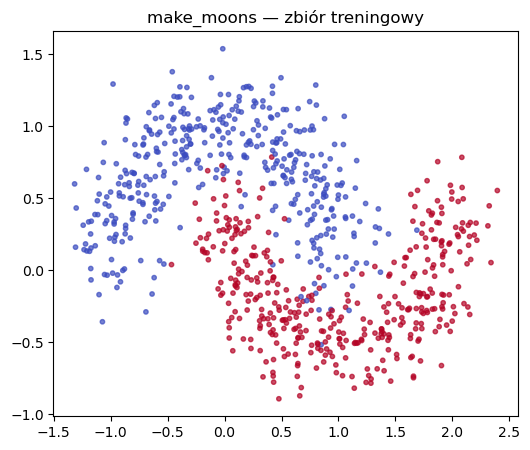

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

X_np, y_np = make_moons(n_samples=1000, noise=0.2, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(X_np, y_np, test_size=0.2, random_state=0)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
X_va = torch.tensor(X_va, dtype=torch.float32)
y_va = torch.tensor(y_va, dtype=torch.long)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="coolwarm", s=10, alpha=0.7)
ax.set_title("make_moons — zbiór treningowy");

Etykiety zapisaliśmy jako `torch.long`, bo tego oczekuje `CrossEntropyLoss`.

Definiujemy model — MLP z jedną warstwą ukrytą o szerokości 16, dwoma logitami na wyjściu (po jednym na klasę):

In [60]:
class MoonsMLP(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.fc2 = nn.Linear(hidden, 2)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

model = MoonsMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True
)

Pętla treningowa:

In [61]:
num_epochs = 50
hist_train, hist_val = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(Xb)
    hist_train.append(epoch_loss / len(X_tr))

    model.eval()
    with torch.no_grad():
        val_logits = model(X_va)
        val_loss = criterion(val_logits, y_va).item()
        val_acc = (val_logits.argmax(dim=1) == y_va).float().mean().item()
    hist_val.append(val_loss)

print(f"Po {num_epochs} epokach: val_loss = {hist_val[-1]:.4f}, val_acc = {val_acc:.3f}")

Po 50 epokach: val_loss = 0.1057, val_acc = 0.955


Krzywe uczenia i granica decyzyjna:

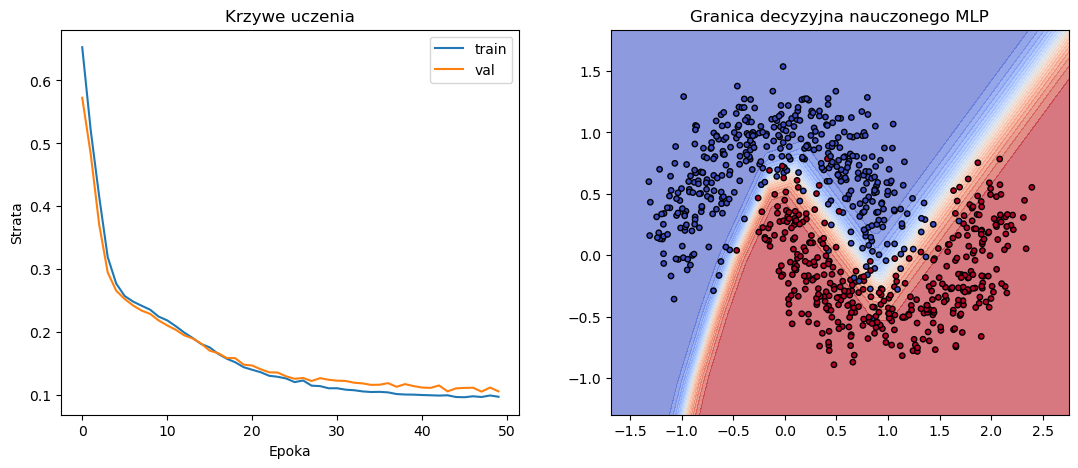

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist_train, label="train")
axes[0].plot(hist_val, label="val")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Strata")
axes[0].set_title("Krzywe uczenia"); axes[0].legend()

# Granica decyzyjna na siatce 2D
xx, yy = np.meshgrid(
    np.linspace(X_np[:, 0].min() - 0.3, X_np[:, 0].max() + 0.3, 200),
    np.linspace(X_np[:, 1].min() - 0.3, X_np[:, 1].max() + 0.3, 200),
)
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
model.eval()
with torch.no_grad():
    probs = F.softmax(model(grid), dim=1)[:, 1].numpy().reshape(xx.shape)

axes[1].contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.6)
axes[1].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="coolwarm",
                edgecolor="k", s=15)
axes[1].set_title("Granica decyzyjna nauczonego MLP");

MLP z jedną warstwą ukrytą i nieliniową aktywacją bez problemu uczy się nieliniowej granicy decyzyjnej w kształcie dwóch przeplatających się półksiężyców. Regresja logistyczna, ograniczona do hiperpłaszczyzny, nie miałaby na to szans.

Zwróćmy uwagę, jak różny jest ten kod od sieci „od dołu" z sekcji 5 pod względem ilości pisania, mimo że pod spodem dzieje się dokładnie to samo: forward, backward, krok optymalizatora.

## Podsumowanie

Wykład 5 wprowadził mechanizm, który zwalnia nas z ręcznego wyprowadzania gradientów — i tym samym otwiera drogę do trenowania modeli o praktycznie dowolnej architekturze.

* **Graf obliczeniowy** — każda sekwencja operacji tensorowych ma postać DAG-u, którego liście to dane i parametry, a korzeń to skalar straty.
* **Wsteczna propagacja** — algorytm liczący wszystkie gradienty w jednym przejściu po grafie, od korzenia do liści, w czasie tego samego rzędu co forward pass.
* **Autograd w PyTorch** — `requires_grad=True`, dynamiczne budowanie grafu, `loss.backward()` i atrybut `.grad`. Wyłączanie śledzenia: `torch.no_grad()`, `.detach()`. Akumulacja gradientów wymusza zerowanie po każdej iteracji.
* **`torch.nn`** — `nn.Module` jako klasa bazowa, `nn.Linear` i inne warstwy, funkcje aktywacji jako klasy lub funkcje, `nn.Sequential` dla prostych modeli.
* **Funkcje straty** — `MSELoss`, `BCEWithLogitsLoss`, `CrossEntropyLoss`. Dwie ostatnie przyjmują logity, a nie prawdopodobieństwa.
* **Optymalizatory** — `optim.SGD` jako odpowiednik tego, co liczyliśmy ręcznie; `optim.Adam` jako rozsądny domyślny wybór z adaptacyjnym lr per parametr.
* **Kanoniczna pętla treningowa** — `zero_grad → forward → loss → backward → step`, plus `model.train()`/`model.eval()` i `torch.no_grad()` w walidacji.

Wszystko to wystarczy do zbudowania i wytrenowania sieci w pełni połączonej (MLP) o dowolnej głębokości i szerokości. Co taki model ogarnia nie najgorzej: dane tabelaryczne, problemy regresji i klasyfikacji o umiarkowanej liczbie cech. Co ogarnia źle: obrazy. Liczba parametrów rośnie kwadratowo z rozdzielczością, a model nie ma żadnej wbudowanej wiedzy o lokalności i niezmienniczości translacyjnej. Jak to obejść — temat wykładu 6 o sieciach konwolucyjnych.